# Part III: Multivariate MMAR for joint markets

The screener reused one univariate model independently across stocks. This notebook instead extends that model to a coherent three-asset system. The new ingredients are a shared cascade tree, correlated multivariate Student-$t$ innovations, and a positive-definite correlation model. We will validate both marginal and joint behavior, train a 13-parameter amortized estimator, and propagate joint uncertainty into portfolio risk and allocation.

In [1]:
from pathlib import Path

import bayesflow as bf

from mmar import statistics as stats, viz
from mmar.data import load_market_returns

from mmar import multivariate as model, risk, allocation
from mmar.viz import multivariate as plots

INFO:bayesflow:Multiple Keras-compatible backends detected (JAX, PyTorch, TensorFlow). Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
PRIOR = model.PRIOR
ASSETS = PRIOR.assets
FIGURES_DIR = Path("figures/multivariate")
CHECKPOINT_DIR = Path("checkpoints/multivariate")

viz.configure_plot_style()

## 1. Model specification

The univariate equation is retained asset by asset and stacked into one vector:

$$\mathbf r_t=\boldsymbol\mu+D_t\boldsymbol\varepsilon_t,\qquad
D_t=\operatorname{diag}_{i=1}^{3}\!\left(\bar\sigma_i\sqrt{\theta_{i,t}(q_i)}\right).$$

The Gaussian driver is correlated before one shared radial scale creates the innovation vector:

$$\mathbf z_t=L\mathbf g_t,\qquad \mathbf g_t\overset{\mathrm{iid}}{\sim}N_3(\mathbf0,I_3),\qquad LL^\top=R,$$
$$\boldsymbol\varepsilon_t=\mathbf z_t\sqrt{(\nu-2)/U_t},\qquad
U_t\overset{\mathrm{iid}}{\sim}\chi^2_\nu.$$

Equivalently, $\boldsymbol\varepsilon_t\sim t_{\nu,3}(\mathbf0,(\nu-2)R/\nu)$, where the second argument is the Student-$t$ **scale** matrix; $\operatorname{Cov}(\boldsymbol\varepsilon_t)=R$. Sharing $U_t$ across the three assets gives contemporaneous joint tail events.

Relative to the scalar model:

- $\mathbf r_t$ and $\boldsymbol\mu$ collect the three returns and daily drifts; $D_t$ collects their cascade-modulated scales.
- $\mathbf g_t$ is an independent standard-Gaussian seed; $\mathbf z_t=L\mathbf g_t$ is its correlated Gaussian driver, with correlation matrix $R$ and Cholesky factor $L$.
- $U_t$ is a chi-square radial variable shared by the assets on day $t$; $\boldsymbol\varepsilon_t$ is the resulting standardized multivariate Student-$t$ innovation.
- Each asset keeps its own $\bar\sigma_i$ and $q_i$. Split orientations and the circular phase are shared, so the cascade can align turbulent regimes without forcing equal intensity.

The estimator learns 13 coordinates: three drifts, three scales, three cascade strengths, one shared $\nu$, and three vine coordinates $(a,b,c)$ for $R$. Here $a=\rho_{\mathrm{VOO,GLD}}$, $b=\rho_{\mathrm{VOO,TLT}}$, and $c=\rho_{\mathrm{GLD,TLT}\mid\mathrm{VOO}}$, giving

$$\rho_{\mathrm{GLD,TLT}}=ab+c\sqrt{(1-a^2)(1-b^2)}.$$

Any $(a,b,c)\in(-1,1)^3$ reconstructs a positive-definite $R$. The simulator places a normalized Wishart prior on $R$ and then converts each draw to $(a,b,c)$.

In [3]:
model.prior_table(PRIOR)

,prior,meaning
parameter,,
mu[VOO],"Normal(0, 0.0015²)",VOO daily drift
sigma_bar[VOO],"Uniform(0.005, 0.025)",VOO baseline RMS return scale
q[VOO],"Uniform(0.52, 0.9)",VOO cascade contrast and volatility intermittency
mu[GLD],"Normal(0, 0.0015²)",GLD daily drift
sigma_bar[GLD],"Uniform(0.005, 0.025)",GLD baseline RMS return scale
q[GLD],"Uniform(0.52, 0.9)",GLD cascade contrast and volatility intermittency
mu[TLT],"Normal(0, 0.0015²)",TLT daily drift
sigma_bar[TLT],"Uniform(0.005, 0.025)",TLT baseline RMS return scale
q[TLT],"Uniform(0.52, 0.9)",TLT cascade contrast and volatility intermittency


In [4]:
observed_returns = load_market_returns(ASSETS, start="2015-01-01", end="2026-09-01")
observed_window = observed_returns.tail(model.WINDOW)

## 2. Prior predictive checks

The checks now have two layers. Marginal return and drawdown plots verify each ETF separately; signed-return correlation, absolute-return correlation, and the equal-weight portfolio probe the new joint structure. In particular, absolute-return correlation tests whether the shared cascade produces plausible co-volatility.

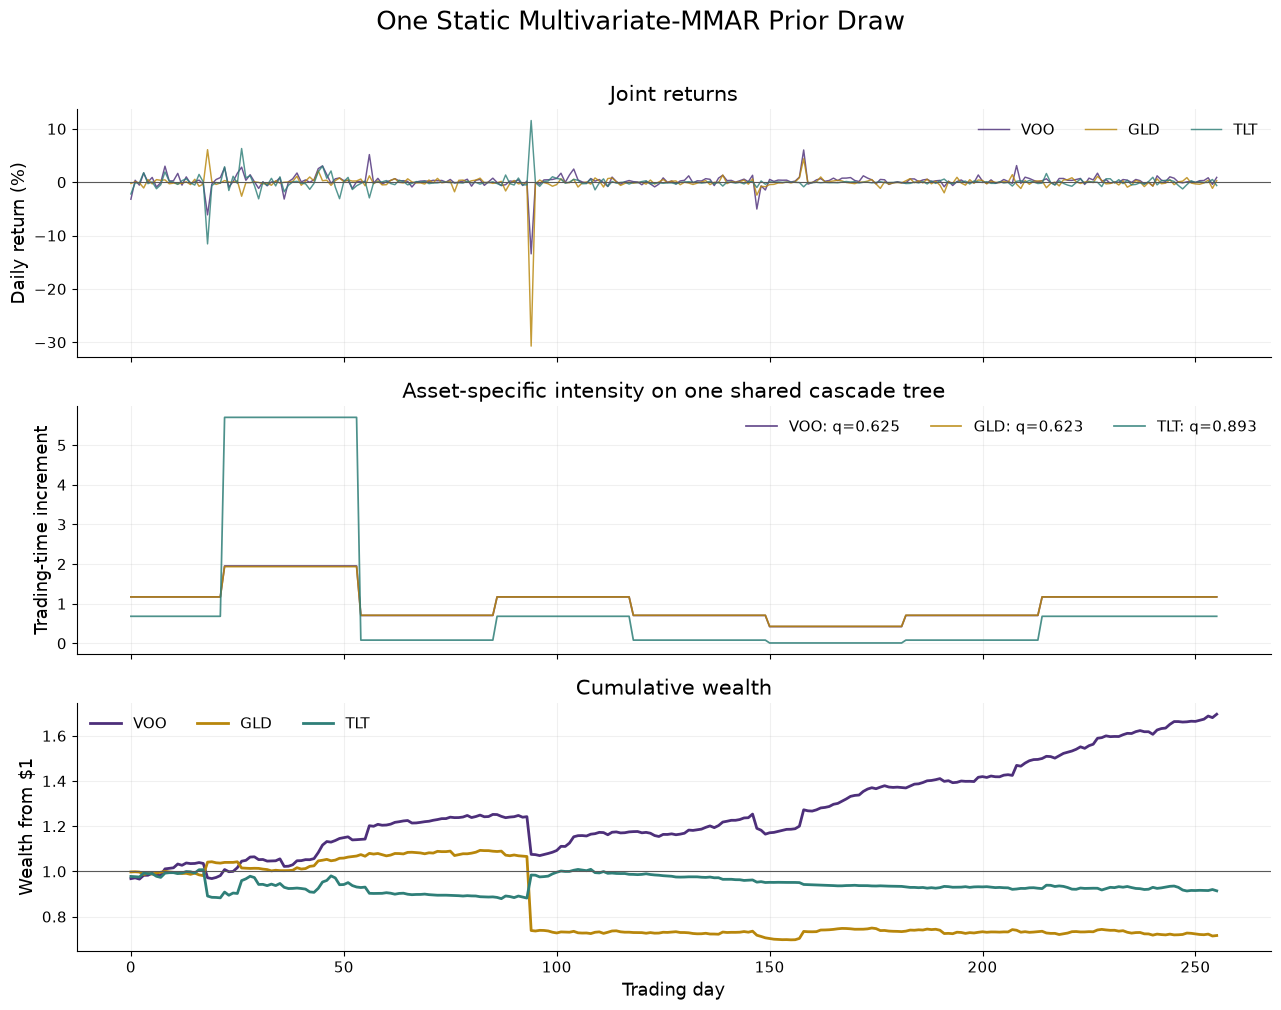

In [6]:
prior_simulations = model.simulate(4_000, seed=555, prior=PRIOR)
prior_returns = prior_simulations["returns"]

fig = plots.plot_example_paths(prior_simulations, assets=ASSETS)
_ = viz.save_figure(fig, "01_example_joint_prior_path.png", FIGURES_DIR)

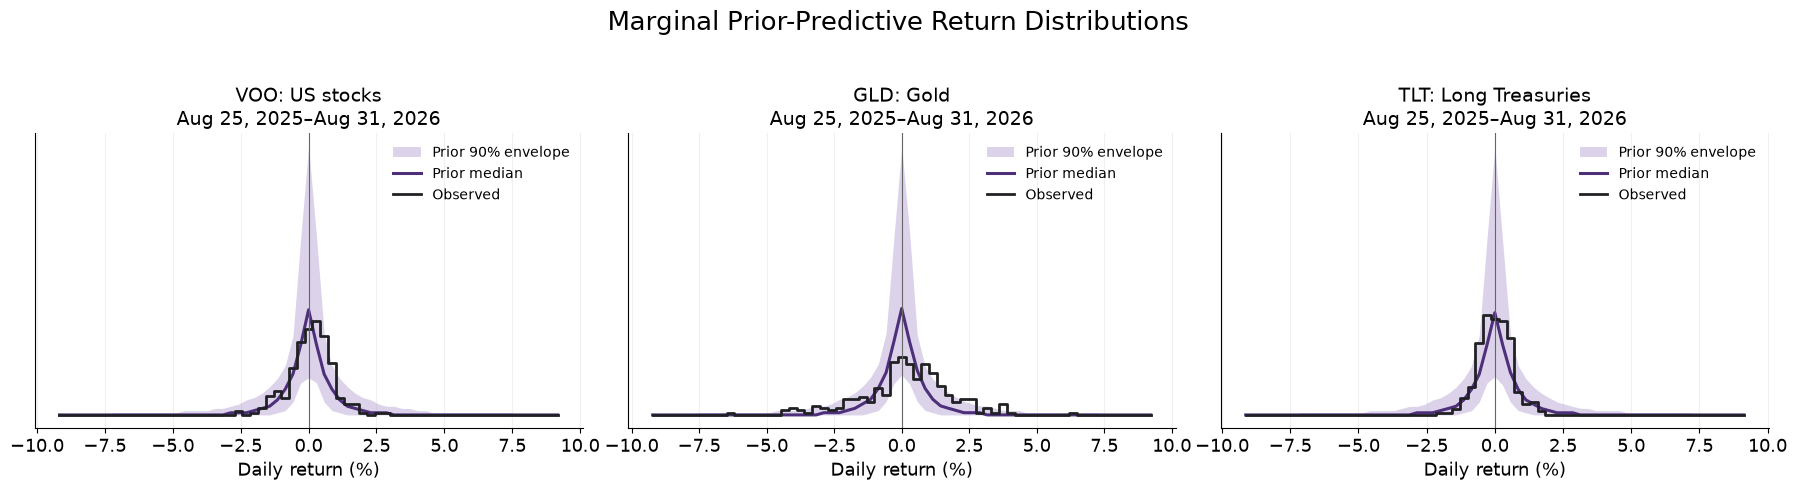

In [7]:
fig = plots.plot_marginal_return_envelopes(prior_returns, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "02_marginal_return_envelopes.png", FIGURES_DIR)

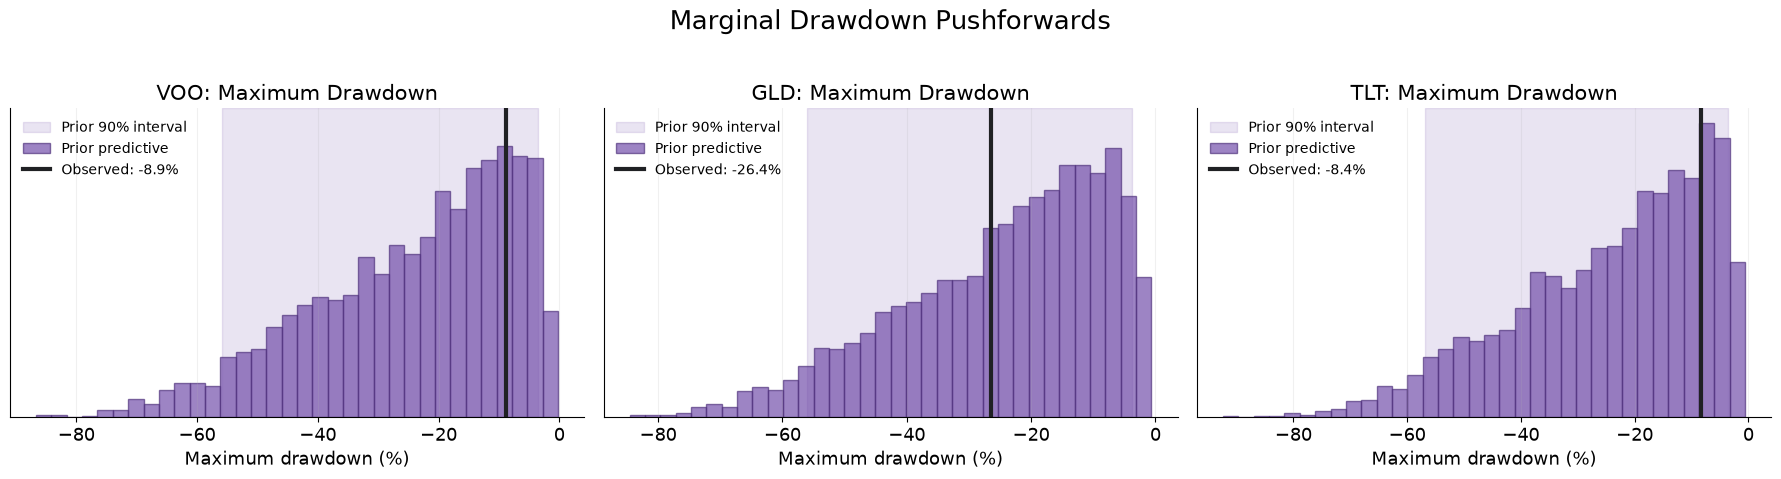

In [8]:
fig = plots.plot_marginal_drawdowns(prior_returns, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "03_marginal_drawdown_checks.png", FIGURES_DIR)

In [9]:
marginal_table = stats.marginal_pushforward_table(prior_returns, observed_window, assets=ASSETS)
marginal_table.style.format(precision=2)

,asset,stat,observed_pct,prior_q05_pct,prior_q95_pct,inside_prior_interval
0,VOO,mean_pct,0.08,-0.28,0.29,True
1,VOO,avg_abs_return_pct,0.61,0.26,1.53,True
2,VOO,volatility_pct,0.80,0.39,2.37,True
3,VOO,q01_pct,-1.89,-6.60,-0.96,True
4,VOO,q05_pct,-1.39,-3.36,-0.42,True
5,VOO,expected_shortfall_5_pct,-1.77,-5.57,-0.85,True
6,VOO,max_drawdown_pct,-8.90,-55.84,-3.48,True
7,GLD,mean_pct,0.12,-0.29,0.28,True
8,GLD,avg_abs_return_pct,1.30,0.26,1.54,True
9,GLD,volatility_pct,1.81,0.40,2.41,True


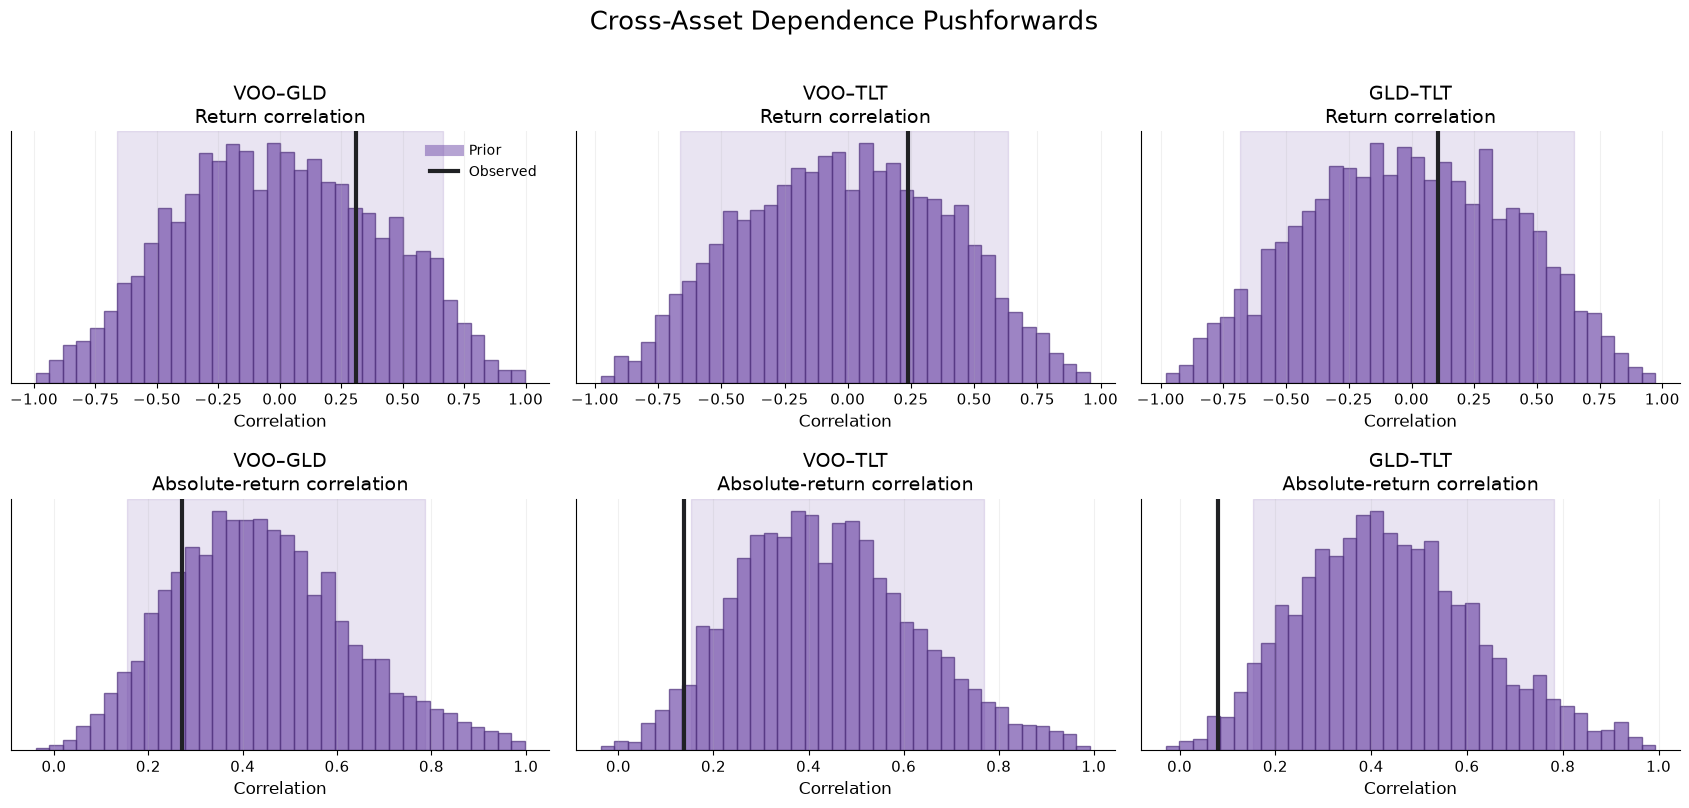

In [10]:
fig = plots.plot_dependence_pushforwards(prior_returns, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "04_cross_asset_dependence.png", FIGURES_DIR)

In [11]:
dependence_table = stats.dependence_pushforward_table(prior_returns, observed_window, assets=ASSETS)
dependence_table.style.format(precision=2)

,pair,stat,observed,prior_q05,prior_q95,unit,inside_prior_90pct_interval
0,VOO–GLD,return_correlation,0.31,-0.66,0.67,correlation,True
1,VOO–GLD,absolute_return_correlation,0.27,0.16,0.79,correlation,True
2,VOO–GLD,joint_downside_probability,1.56,0.00,2.34,%,True
3,VOO–TLT,return_correlation,0.24,-0.66,0.63,correlation,True
4,VOO–TLT,absolute_return_correlation,0.14,0.15,0.77,correlation,False
5,VOO–TLT,joint_downside_probability,1.17,0.00,2.34,%,True
6,GLD–TLT,return_correlation,0.11,-0.68,0.65,correlation,True
7,GLD–TLT,absolute_return_correlation,0.08,0.15,0.78,correlation,False
8,GLD–TLT,joint_downside_probability,0.00,0.00,2.34,%,True


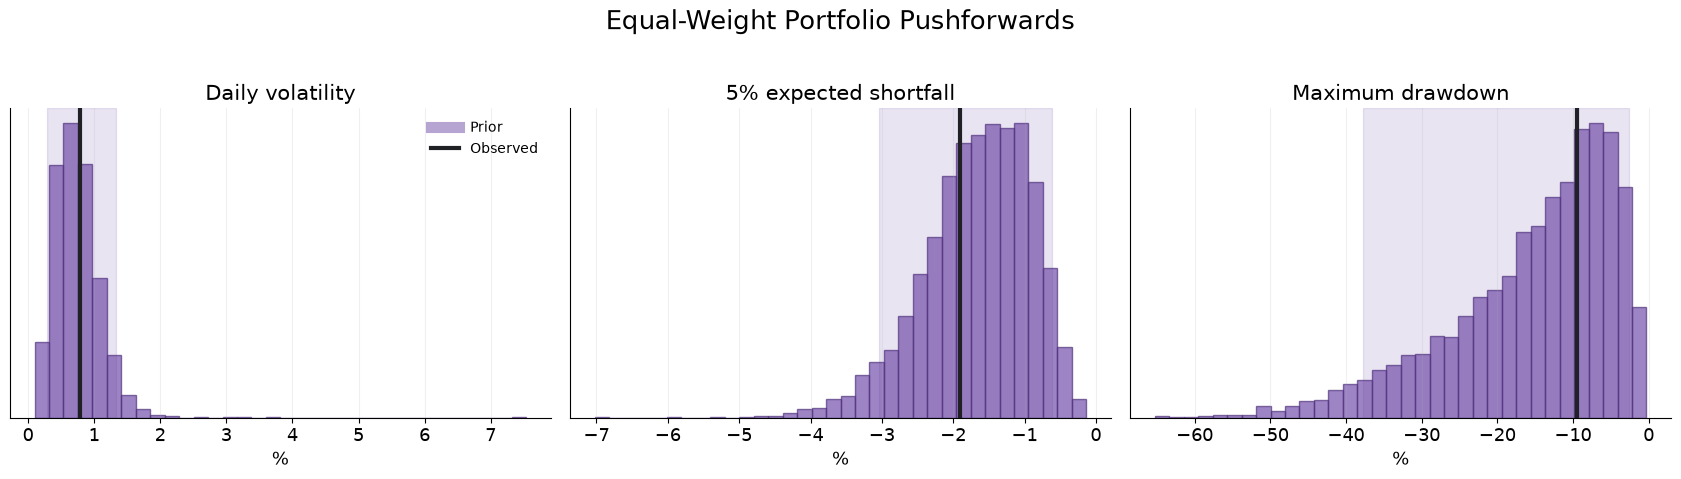

In [12]:
fig = plots.plot_equal_weight_portfolio_checks(prior_returns, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "05_equal_weight_portfolio_checks.png", FIGURES_DIR)

## 3. Simulation-based amortized inference

Here, `model.simulate` returns joint parameter draws and their $256\times3$ return paths. The adapter maps bounded parameters back to original units and represents $R$ through its three valid vine coordinates.

In [13]:
sigma_keys = tuple(f"sigma_bar_{asset}" for asset in ASSETS)
q_keys = tuple(f"q_{asset}" for asset in ASSETS)

adapter = bf.Adapter().split("sigma_bar", into=sigma_keys).split("q", into=q_keys)
for key, lower, upper in zip(sigma_keys, PRIOR.sigma_bar_low, PRIOR.sigma_bar_high):
    adapter.constrain(key, lower=lower, upper=upper)
for key, lower, upper in zip(q_keys, PRIOR.q_low, PRIOR.q_high):
    adapter.constrain(key, lower=lower, upper=upper)

adapter = (
    adapter
    .constrain("nu", lower=PRIOR.nu_low, upper=PRIOR.nu_high)
    .constrain("correlation_partials", lower=-1.0, upper=1.0)
    .concatenate(("mu", *sigma_keys, *q_keys, "nu", "correlation_partials"), into="inference_variables")
    .rename("returns", "summary_variables")
)

workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=bf.networks.FusionTransformer(),
    inference_network=bf.networks.CouplingFlow(transform="spline", depth=4),
    standardize="all",
    checkpoint_filepath=CHECKPOINT_DIR,
    save_best_only=True
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To restore the approximator from the checkpoint, call workflow.load_approximator() or pass restore=True to the workflow constructor.


In [12]:
training_simulations = model.simulate(100_000, prior=PRIOR)
validation_simulations = model.simulate(100, prior=PRIOR)

In [13]:
history = workflow.fit_offline(
    data=training_simulations, 
    validation_data=validation_simulations, 
    epochs=100, 
    batch_size=128
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - loss: 16.5964 - val_loss: 15.1731
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 14.1663 - val_loss: 11.3973
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 9.0948 - val_loss: 6.2658
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 6.1860 - val_loss: 4.6388
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5.1486 - val_loss: 3.7740
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 4.5305 - val_loss: 3.2195
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 4.1209 - val_loss: 2.9781
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 4.1364 - val_loss: 2.9694
Epoch 9/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 3.4923 - val_loss: 2.5445
Epoch 10/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 3.1687 - val_loss: 2.0620
Epoch 11/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.9343 - val_loss: 1.7790
Epoch 12/100
782/782 ━━━━

INFO:bayesflow:Training completed in 15.05 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'checkpoints/multivariate/model.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("checkpoints/multivariate/model.keras")


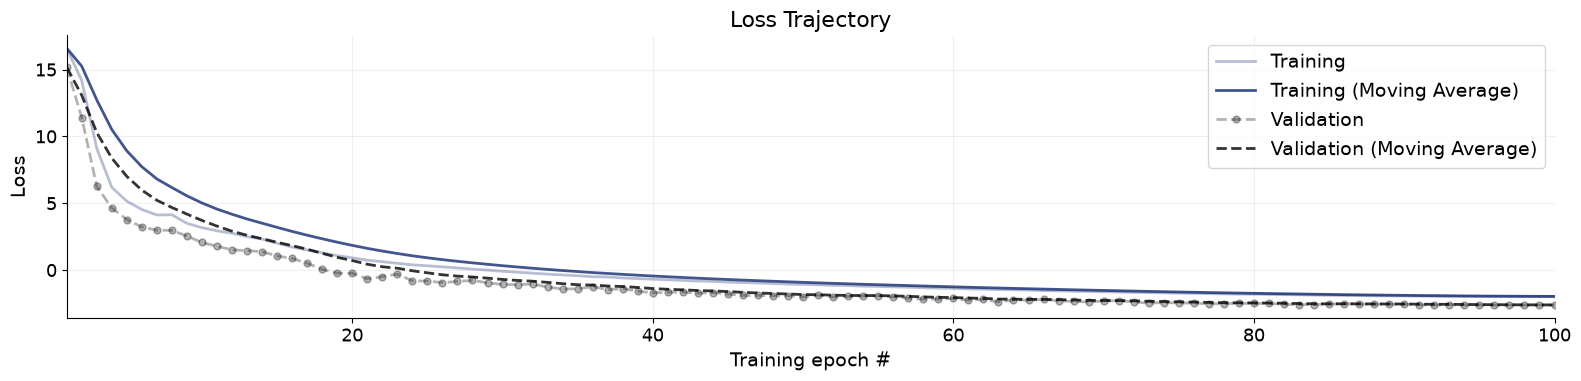

In [14]:
fig = bf.diagnostics.loss(history)
_ = viz.save_figure(fig, "06_training_loss.png", FIGURES_DIR)

## 4. Parameter recovery and calibration

Before interpreting real data, fresh simulated markets provide known ground truth. Recovery measures accuracy and posterior precision; simulation-based calibration checks repeated-simulation coverage. Both matter here because $q_i$, $\nu$, and the dependence coordinates can otherwise trade off.

In [14]:
workflow.load_approximator()

INFO:bayesflow:Approximator restored from 'checkpoints/multivariate/model.keras'.


In [15]:
test_simulations = model.simulate(300, prior=PRIOR)
targets = model.stack_parameters(test_simulations)

In [ ]:
estimates = workflow.sample(conditions=test_simulations, num_samples=1000)
estimates = model.stack_parameters(estimates)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 12.91 seconds.


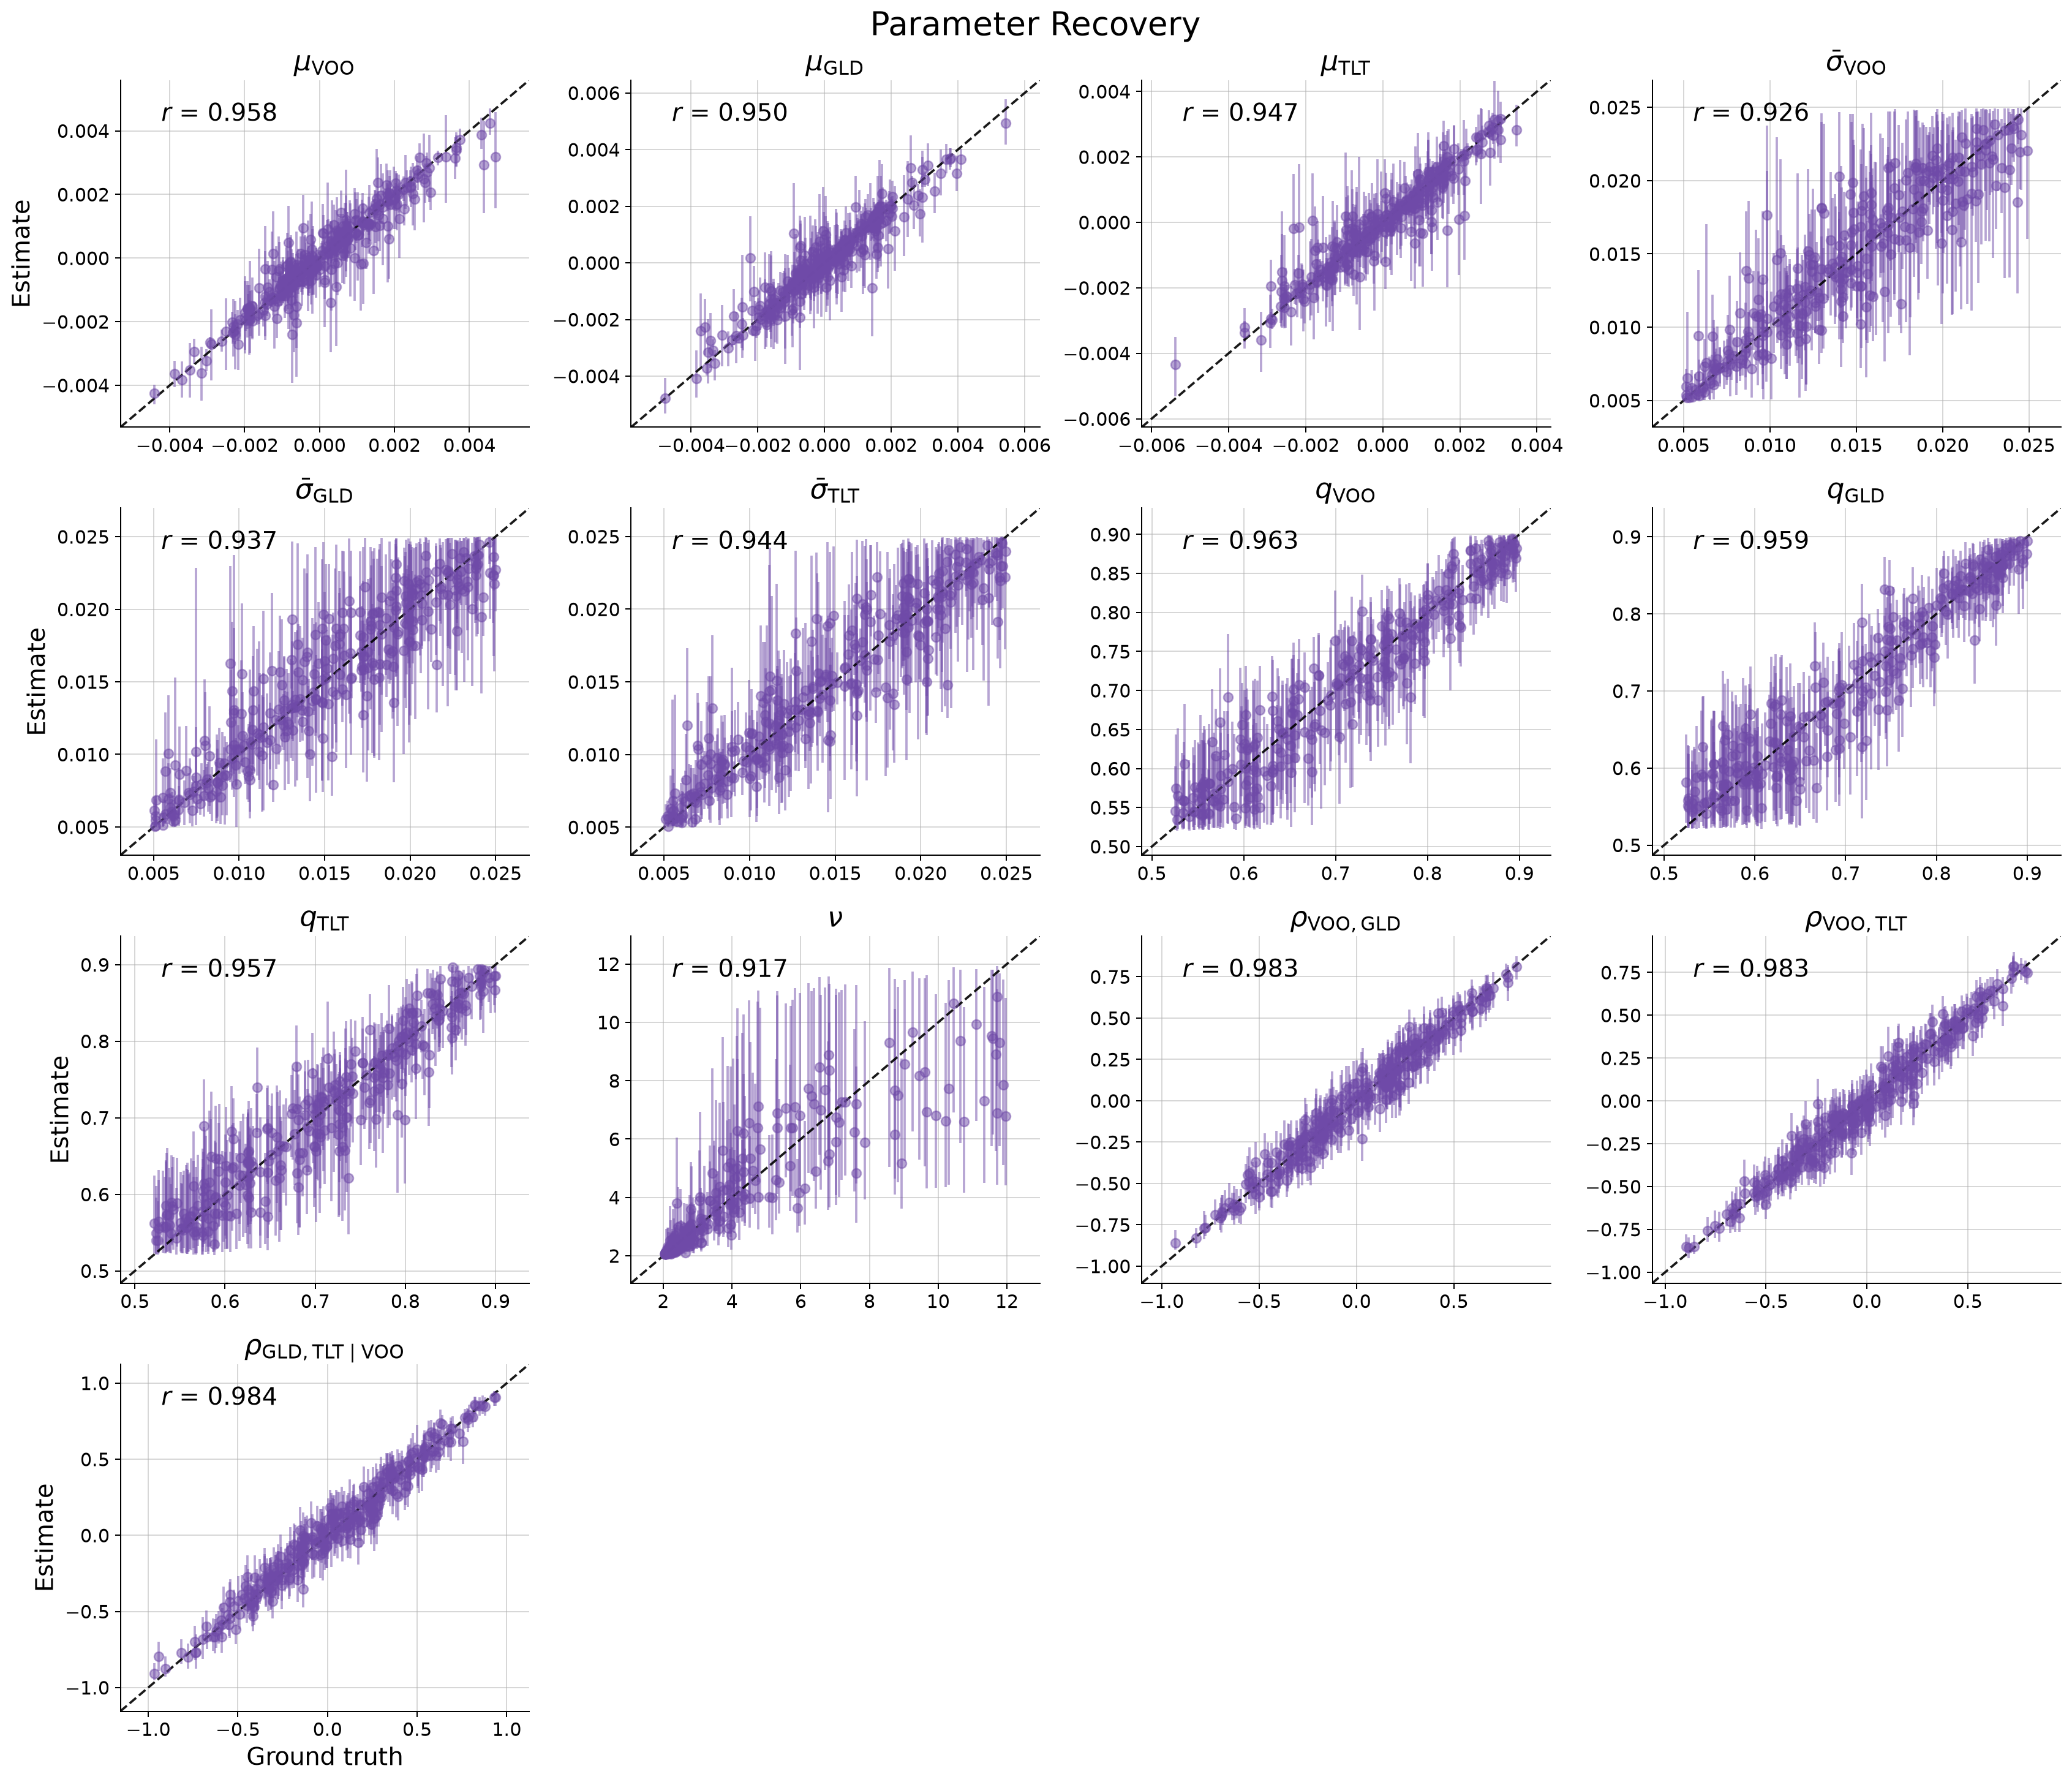

In [14]:
fig = viz.plot_recovery(estimates, targets, model.PARAMETER_LABELS, grid=(4, 4), interval=0.92)
_ = viz.save_figure(fig, "07_parameter_recovery.png", FIGURES_DIR)

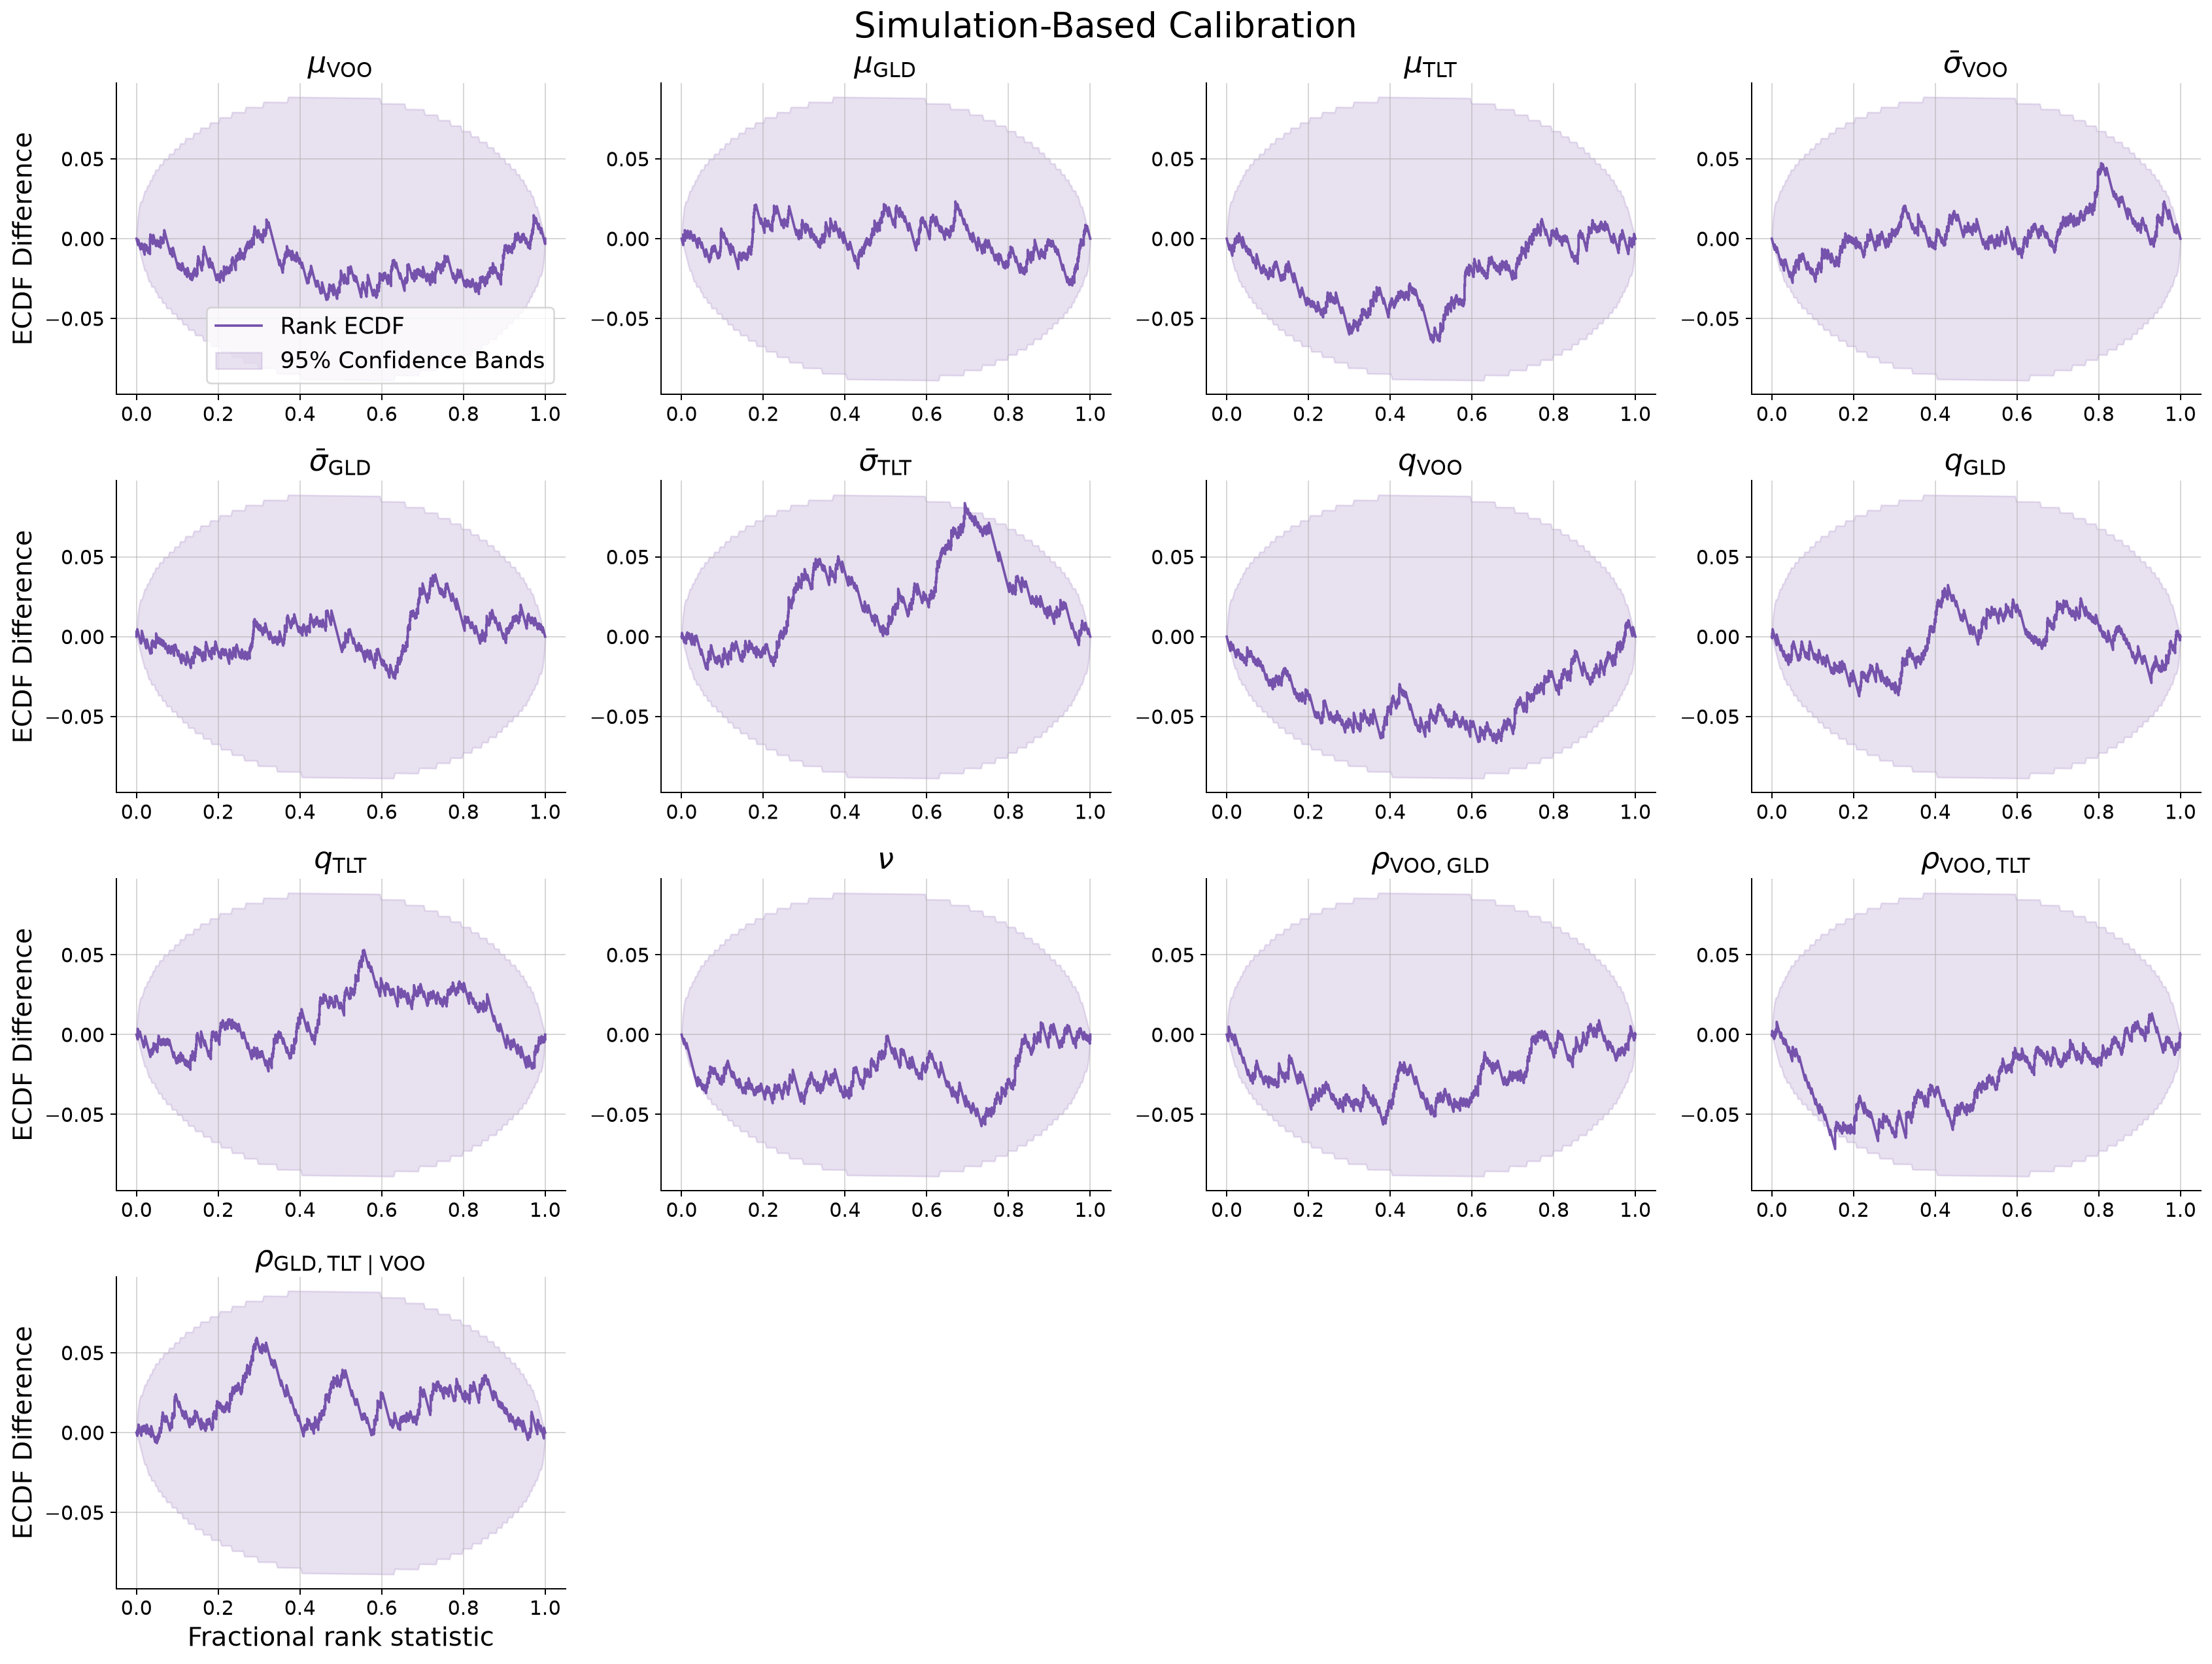

In [15]:
fig = viz.plot_calibration(estimates, targets, model.PARAMETER_LABELS, grid=(4, 4), alpha=0.2)
_ = viz.save_figure(fig, "08_simulation_based_calibration.png", FIGURES_DIR)

In [22]:
table = workflow.compute_default_diagnostics(targets, samples=estimates, variable_names=model.PARAMETER_LABELS)
table

,$\mu_{\mathrm{VOO}}$,$\mu_{\mathrm{GLD}}$,$\mu_{\mathrm{TLT}}$,$\bar\sigma_{\mathrm{VOO}}$,$\bar\sigma_{\mathrm{GLD}}$,$\bar\sigma_{\mathrm{TLT}}$,$q_{\mathrm{VOO}}$,$q_{\mathrm{GLD}}$,$q_{\mathrm{TLT}}$,$\nu$,"$\rho_{\mathrm{VOO,GLD}}$","$\rho_{\mathrm{VOO,TLT}}$","$\rho_{\mathrm{GLD,TLT}\mid\mathrm{VOO}}$"
NRMSE,0.238153,0.235999,0.226301,0.310497,0.304727,0.298596,0.241791,0.283633,0.304898,0.145821,0.185888,0.194841,0.158149
Log Gamma,4.174904,3.255420,4.330637,2.174697,1.474357,-1.829586,4.936486,3.690768,1.761818,1.098079,3.858222,0.867102,1.784873
Calibration Error,0.017982,0.019211,0.006754,0.011842,0.010263,0.025263,0.007368,0.007807,0.013158,0.016228,0.008509,0.042368,0.020965
Posterior Contraction,0.950928,0.953180,0.954399,0.899748,0.905364,0.900660,0.926379,0.910507,0.902506,0.982100,0.962246,0.957536,0.970581


## 5. Posterior predictive checks

Conditioning on the latest joint window, fresh replications retain the inferred cross-asset dependence. Each row checks maximum drawdown, cumulative wealth, and marginal returns for one ETF; drawdown and wealth panels show 68% and 92% predictive intervals. The following figure separately checks signed and absolute-return dependence.

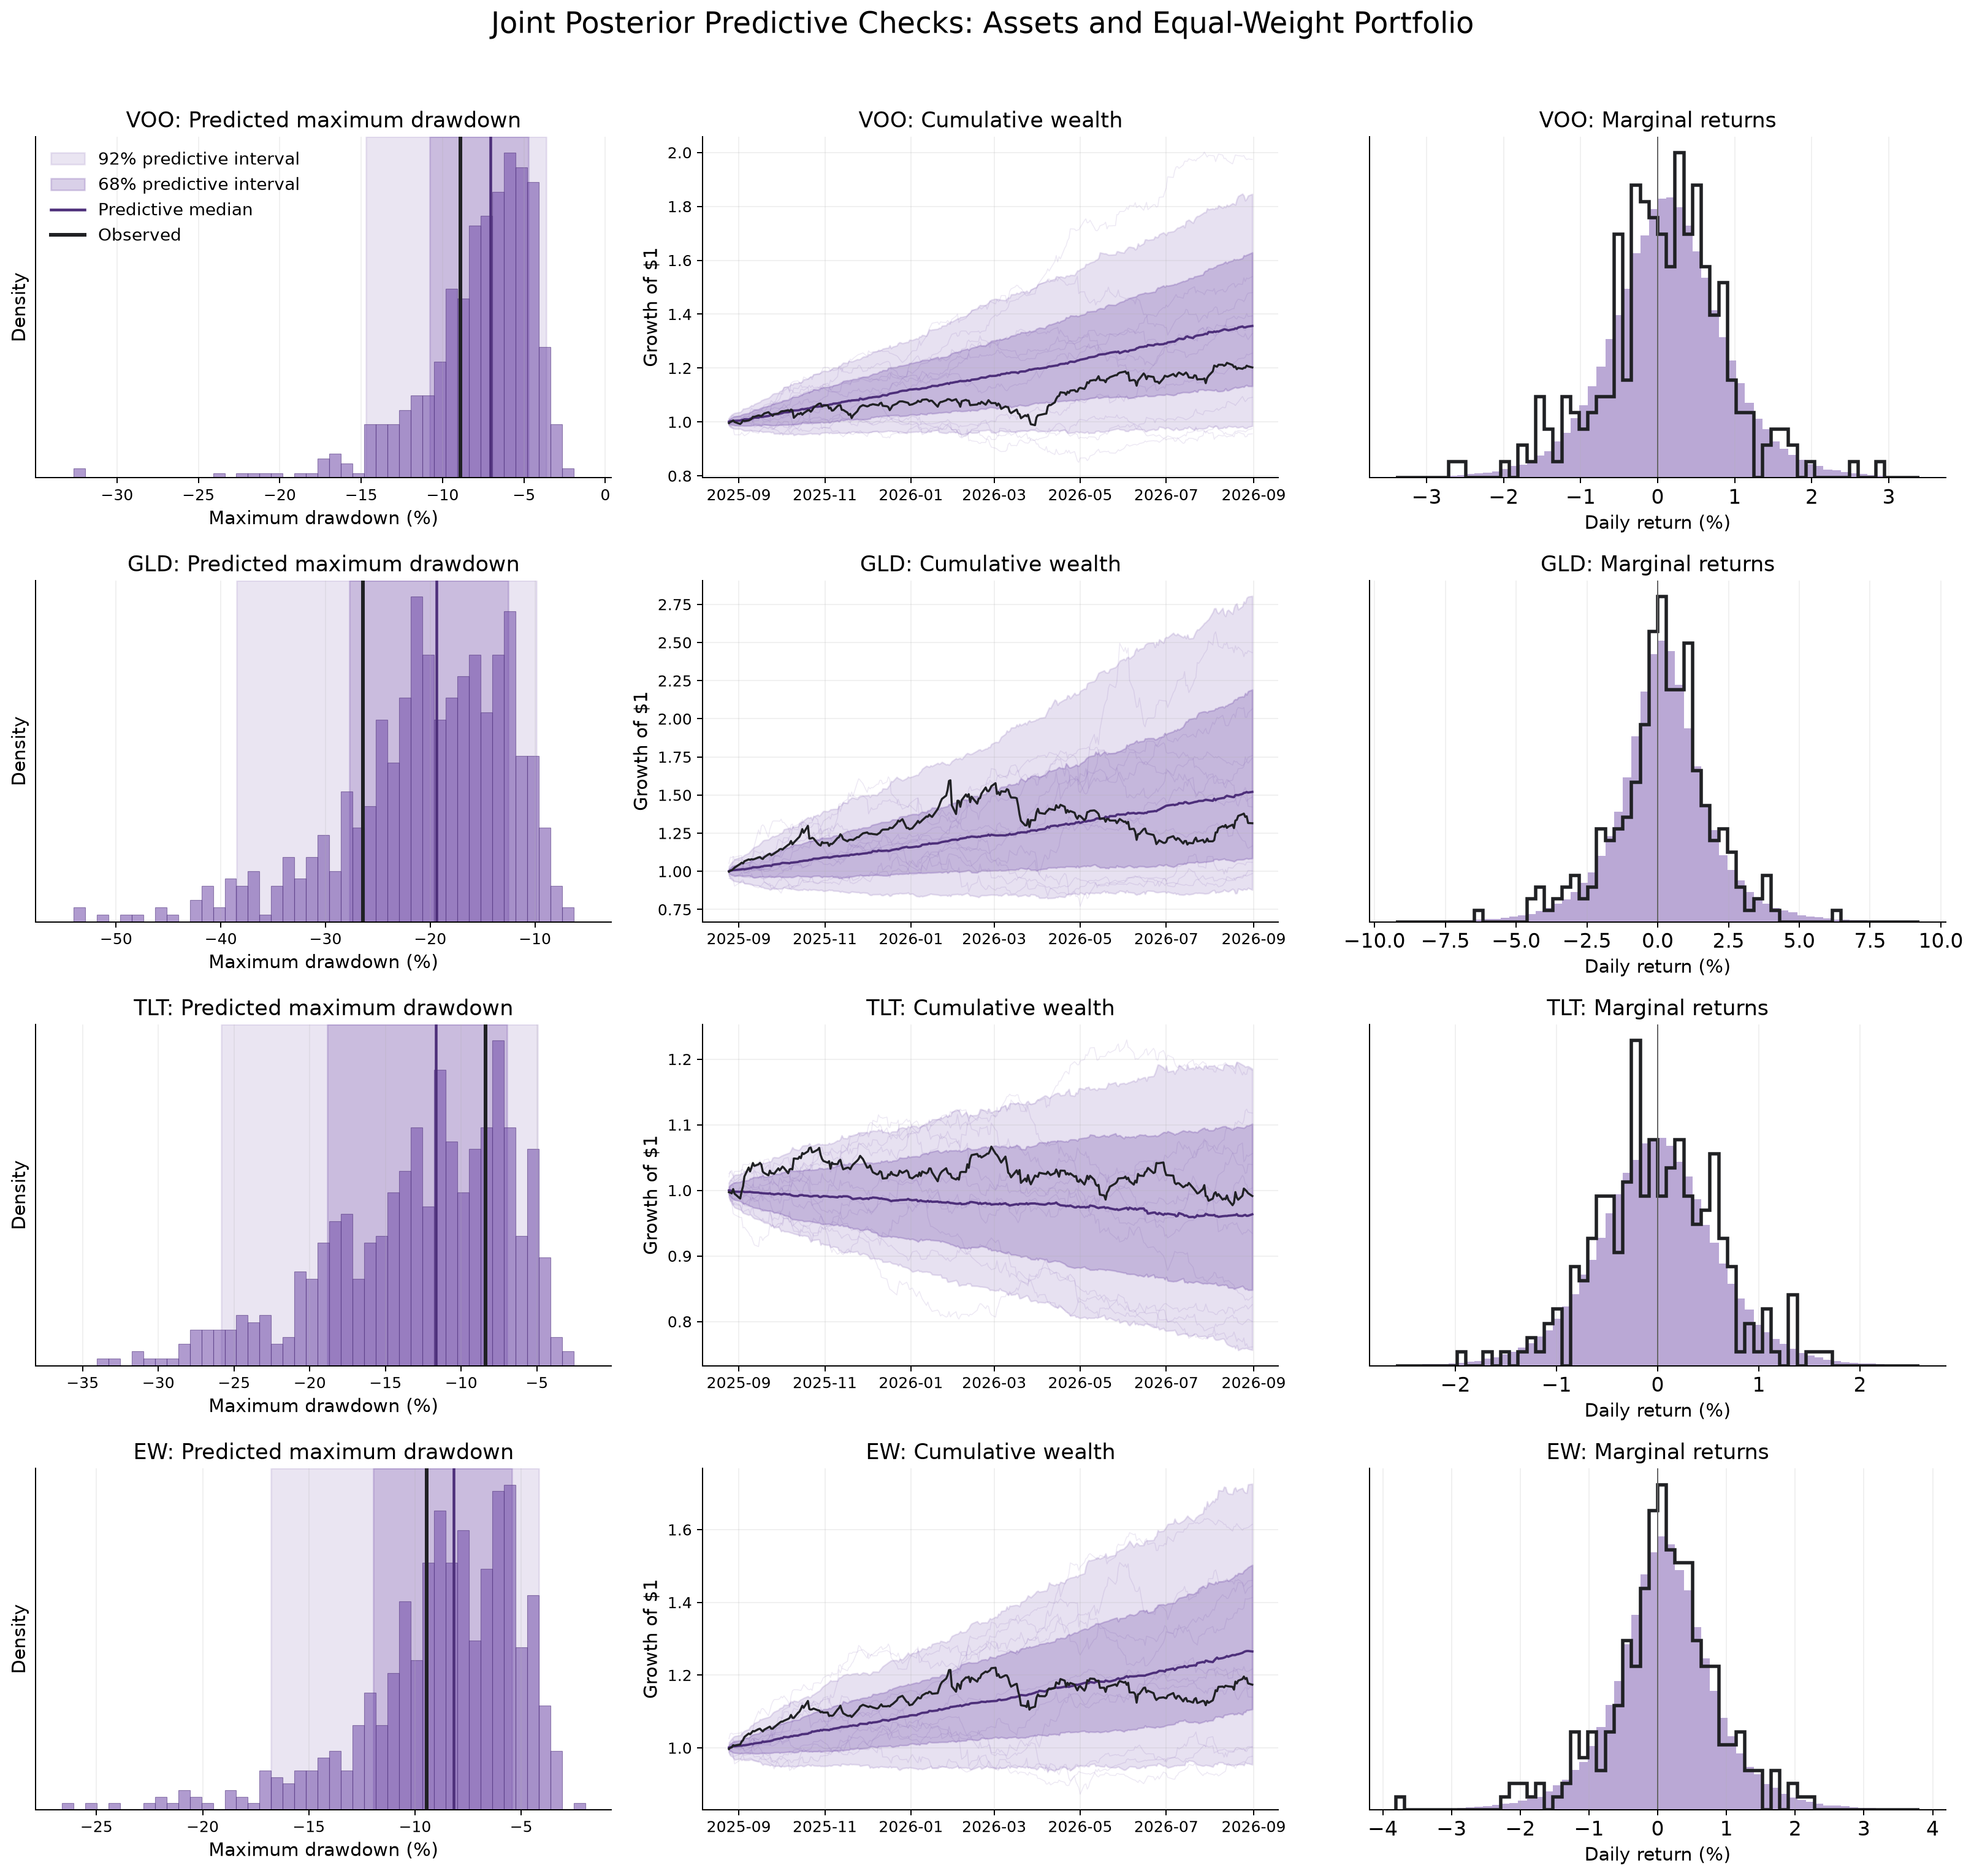

In [16]:
observed_posterior = workflow.sample(
    conditions={"returns": observed_window.to_numpy(dtype="float32")[None, ...]},
    num_samples=600, 
    batch_size=64
)
posterior_paths = model.posterior_resimulations(observed_posterior)[0]

fig = plots.plot_multivariate_posterior_predictive_checks(posterior_paths, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "09_posterior_predictive_checks.png", FIGURES_DIR)

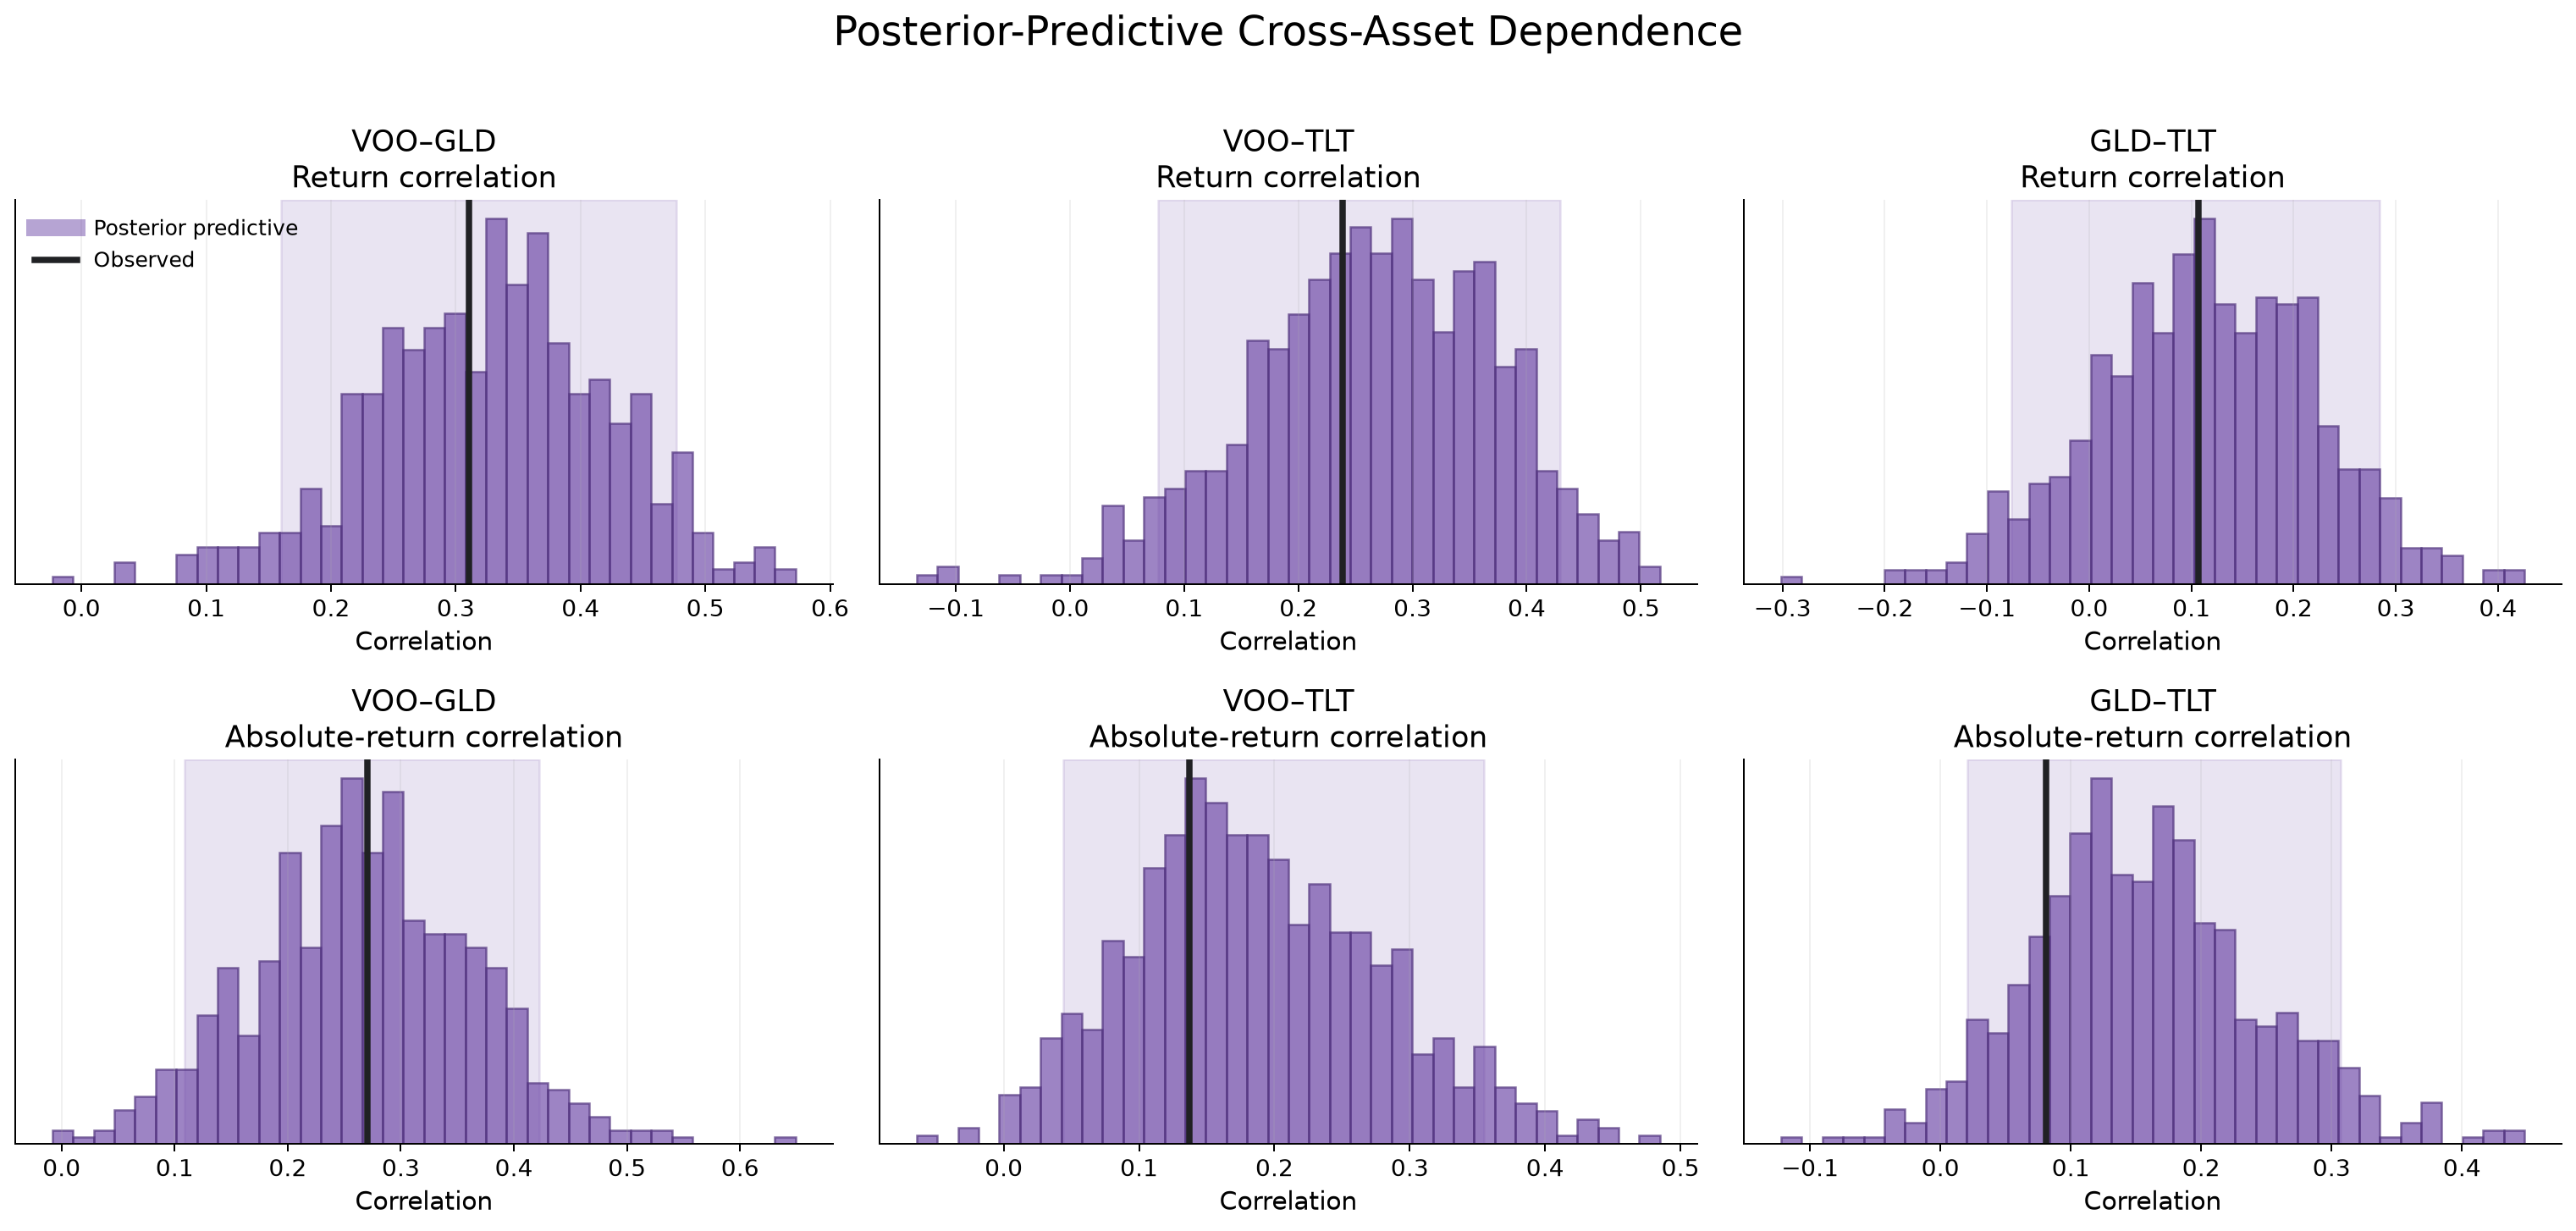

In [17]:
fig = plots.plot_dependence_pushforwards(
    posterior_paths, observed_window, assets=ASSETS,
    predictive_label="Posterior predictive", figure_title="Posterior Predictive Cross-Asset Dependence",
)
_ = viz.save_figure(fig, "10_posterior_dependence_checks.png", FIGURES_DIR)

## 6. Amortized risk estimation

Joint posterior simulations produce coherent returns for each ETF and any portfolio. As in the [univariate notebook](mmar_univariate.ipynb):

- **Value-at-Risk (VaR):** the loss threshold exceeded by only 5% of posterior-predictive outcomes.
- **Expected shortfall (ES):** the average loss within that worst 5%; it measures tail severity beyond VaR.

Let $\mathcal D_t=(\mathbf r_{t-255},\ldots,\mathbf r_t)$ denote the observed joint window. For asset or portfolio $a$ and horizon $h$,

$$R_{t,h}^{(a)}=\prod_{j=1}^{h}(1+\widetilde r_{t+j}^{(a)})-1, \qquad p(R_{t,h}^{(a)}\mid\mathcal D_t)=\int p(R_{t,h}^{(a)}\mid\boldsymbol\phi)\,p(\boldsymbol\phi\mid\mathcal D_t)\,d\boldsymbol\phi.$$

Here $h=20$ trading days. We report rolling VaR and expected shortfall for all three ETFs and the equal-weight portfolio.

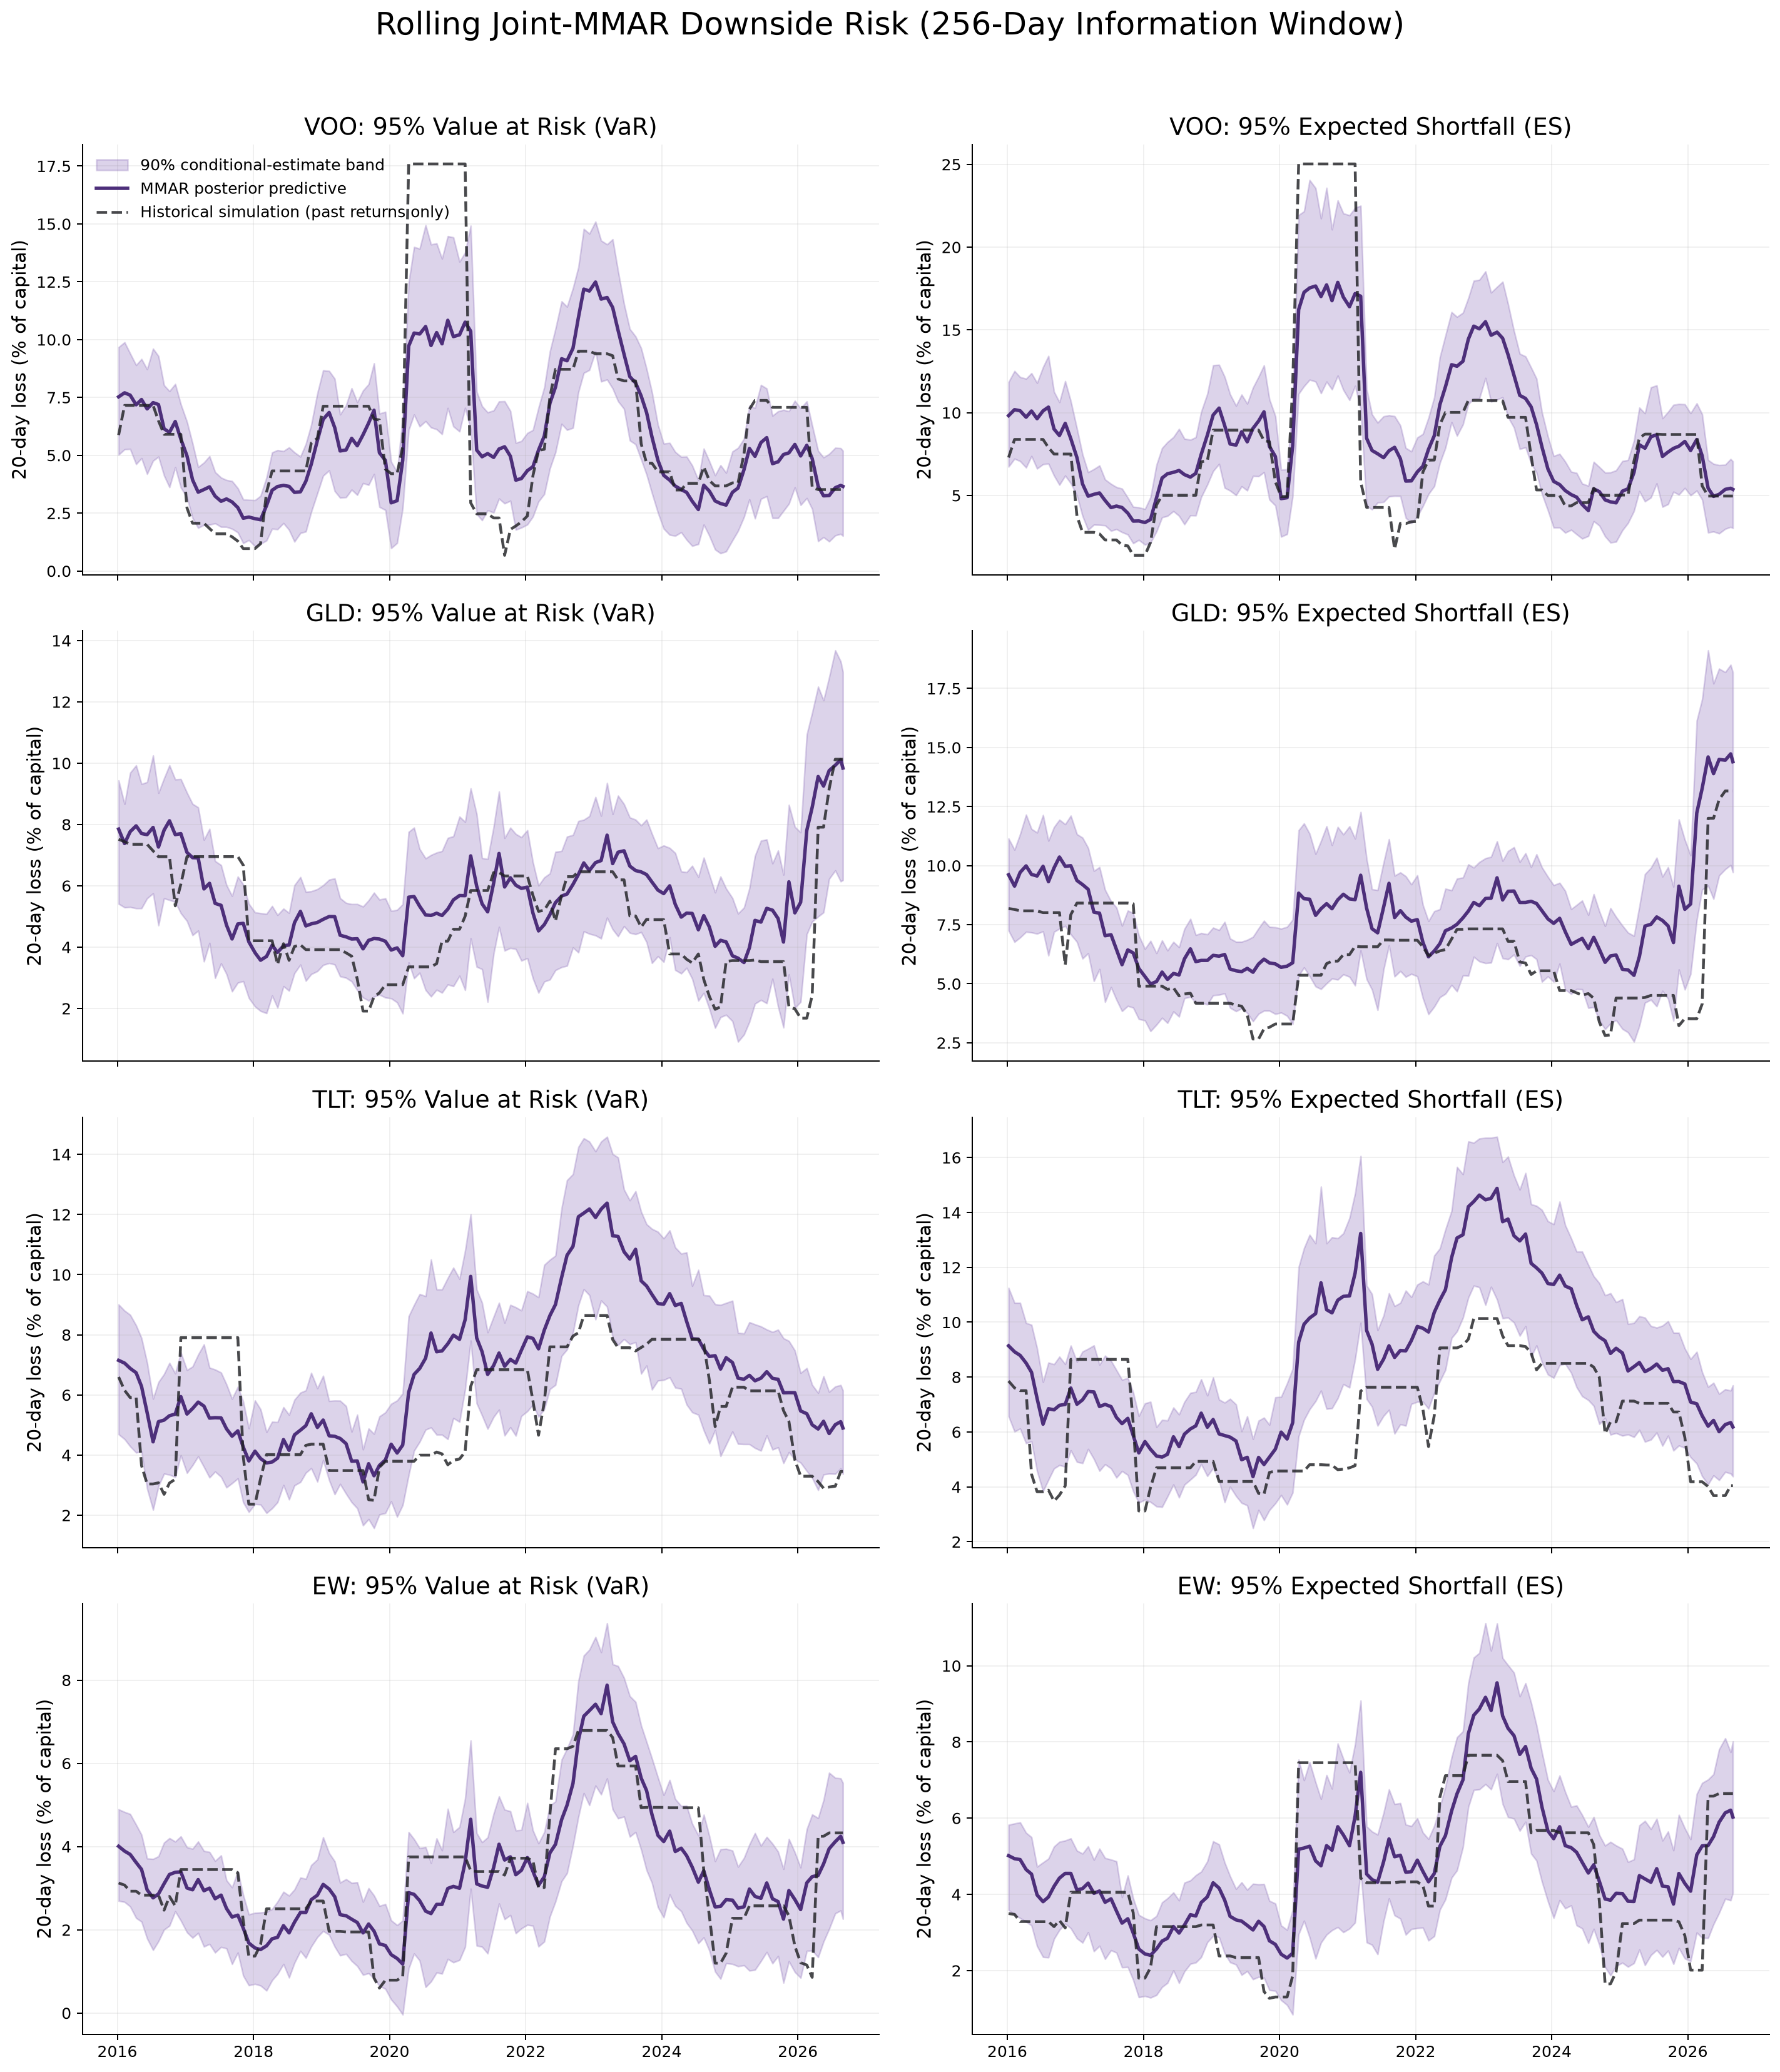

In [18]:
rolling_windows, rolling_metadata = risk.joint_rolling_return_windows(observed_returns, step=21)
rolling_posteriors = workflow.sample(
    conditions={"returns": rolling_windows}, num_samples=500, batch_size=64
)

risk_table = risk.multivariate_posterior_risk_table(
    rolling_posteriors, rolling_metadata, observed_returns,
    horizon=20, n_parameter_draws=160, n_replications=192
)

risk_table.to_csv(FIGURES_DIR / "rolling_risk.csv", index=False)

fig = plots.plot_multivariate_rolling_risk(risk_table, targets=(*ASSETS, "EW"))
_ = viz.save_figure(fig, "11_rolling_var_es.png", FIGURES_DIR)

## 7. Posterior-driven allocation

Joint simulations let every candidate portfolio be evaluated on the same cross-asset scenarios—something separate univariate fits cannot provide. At each decision close $t$, only trailing data select the weights; performance then uses only the observed return at $t+1$. The long-only grid maximizes

$$J_t(\mathbf w)=\operatorname{median}(R_{t,20}^{(\mathbf w)}\mid\mathcal D_t)-0.75\,\operatorname{ES}_{95}^{\mathrm{loss}}(R_{t,20}^{(\mathbf w)}\mid\mathcal D_t),$$

after turnover costs, with a 1 bp no-trade hurdle.

Start with \$1,000. Compare daily and 21-day decisions against VOO buy-and-hold and a three-ETF
"All Weather" proxy (30% VOO, 15% GLD, 55% TLT).

The rebalancing logic goes like this: at each scheduled close, compare holding the drifted weights with every grid candidate. Trade only when the best candidate, after the 10 bp turnover penalty and the scenario's trading fee, beats holding by more than the 1 bp hurdle; otherwise keep the current holdings. One-way turnover is half the sum of absolute weight changes, so cumulative turnover of 1.0 means that one portfolio-equivalent has been reallocated over time.

In [19]:
backtest_windows, backtest_metadata = risk.joint_rolling_return_windows(observed_returns, step=1)
backtest_posteriors = workflow.sample(conditions={"returns": backtest_windows}, num_samples=96, batch_size=64)

allocation_grid = allocation.simplex_weight_grid(step=0.05, min_weight=0.05, max_weight=0.80)
terminal_scenarios = allocation.posterior_terminal_asset_scenarios(
    backtest_posteriors, 
    horizon=20,
    n_parameter_draws=64, 
    n_replications=8
)

backtest = allocation.run_posterior_allocation_backtest(
    observed_returns, backtest_metadata, terminal_scenarios, allocation_grid,
    initial_wealth=1000, rebalance_every=(1, 21), fee_bps=(0, 5, 20),
)

backtest_summary = allocation.allocation_backtest_summary(backtest, initial_wealth=1000)
backtest.to_csv(FIGURES_DIR / "allocation_daily.csv", index=False)
backtest_summary.to_csv(FIGURES_DIR / "allocation_summary.csv", index=False)


Summarizing:   0%|          | 0/42 [00:00<?, ?batch/s]


Summarizing:   2%|▏         | 1/42 [00:00<00:09,  4.47batch/s]


Summarizing:   5%|▍         | 2/42 [00:00<00:08,  4.83batch/s]


Summarizing:   7%|▋         | 3/42 [00:00<00:08,  4.78batch/s]


Summarizing:  10%|▉         | 4/42 [00:00<00:07,  4.92batch/s]

...


Sampling:  88%|████████▊ | 37/42 [00:06<00:00, 11.25batch/s]


Sampling:  93%|█████████▎| 39/42 [00:06<00:00, 11.39batch/s]


Sampling:  98%|█████████▊| 41/42 [00:06<00:00, 11.47batch/s]


Sampling: 100%|██████████| 42/42 [00:09<00:00,  4.56batch/s]


INFO:bayesflow:Sampling completed in 18.58 seconds.


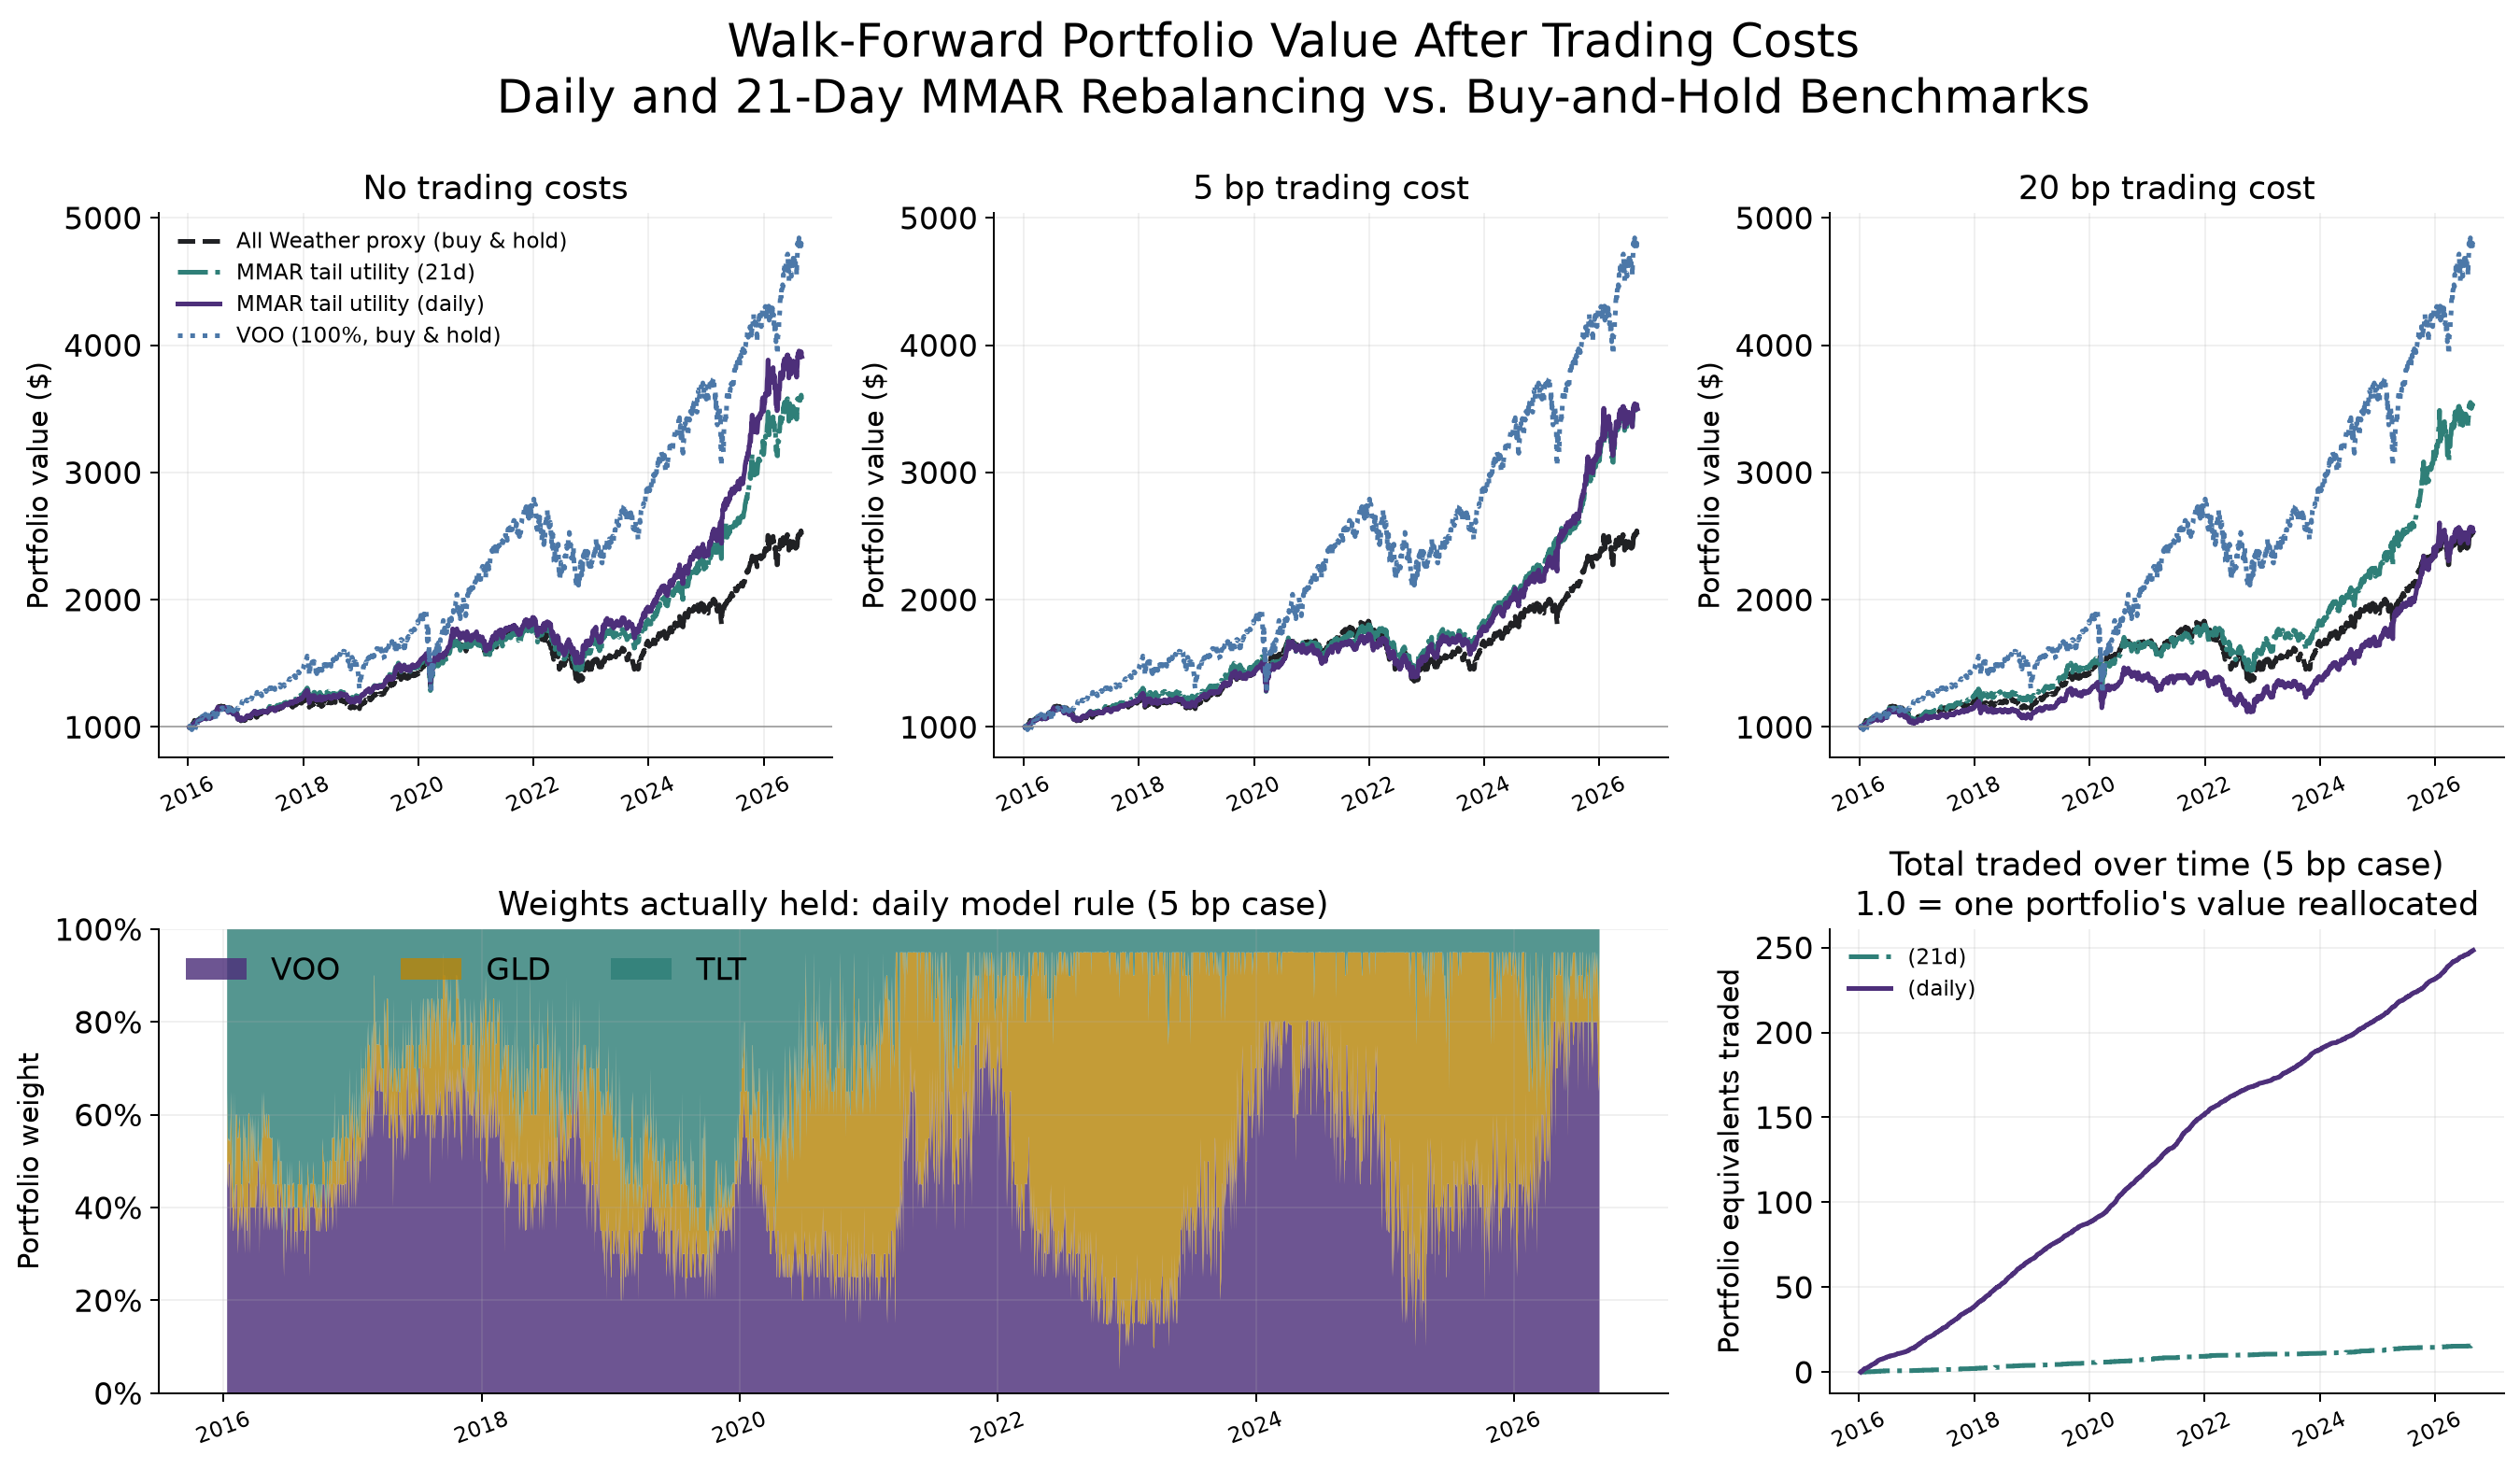

In [20]:
fig = plots.plot_model_allocation_backtest(backtest, initial_wealth=1000, figsize=(18, 9))
_ = viz.save_figure(fig, "12_model_allocation_backtest.png", FIGURES_DIR)

In [21]:
backtest_summary.pivot(index="strategy", columns="fee_bps", values="final_wealth").round(2)

fee_bps,0.0,5.0,20.0
strategy,,,
All Weather proxy (buy & hold),2507.00,2507.00,2507.00
MMAR tail utility (21d),3571.86,3494.95,3510.71
MMAR tail utility (daily),3909.36,3498.45,2537.53
"VOO (100%, buy & hold)",4774.62,4774.62,4774.62


## 8. What the joint model adds

The multivariate extension adds two distinct dependence channels: a shared cascade aligns volatility regimes, while standardized multivariate Student-$t$ innovations capture signed correlation and joint tail events. Estimating them together makes portfolio posterior prediction, risk, and allocation internally coherent. The [final notebook](./mmar_hurst.ipynb) keeps this structure and adds temporal dependence to the Gaussian driver through one Hurst coefficient per asset.